In [1]:
print("Hello")

Hello


In [1]:
print("suite")

suite


In [2]:
print("editing and testing copy")

editing and testing copy


In [1]:
print("testing prsrg")

testing prsrg


In [2]:
print("hello")

hello


In [1]:
print("Networking is live and good")

Networking is live and good


In [3]:
!pip install turtle

ERROR: Could not find a version that satisfies the requirement turtle (from versions: none)
ERROR: No matching distribution found for turtle


In [1]:
import turtle
import math

# Setup screen
screen = turtle.Screen()
screen.bgcolor("white")

pen = turtle.Turtle()
pen.speed(0)
pen.width(2)

# Function to draw a curved kolam loop
def draw_loop(radius):
    for _ in range(4):
        pen.circle(radius, 90)
        pen.circle(radius/2, 90)

# Draw grid of kolam loops
rows = 5
cols = 5
spacing = 60

start_x = -cols * spacing / 2
start_y = rows * spacing / 2

for i in range(rows):
    for j in range(cols):
        x = start_x + j * spacing
        y = start_y - i * spacing
        pen.penup()
        pen.goto(x, y)
        pen.pendown()
        draw_loop(20)

pen.hideturtle()
turtle.done()

TclError: no display name and no $DISPLAY environment variable

In [5]:
!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 25.1 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 42.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 26.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 45.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]


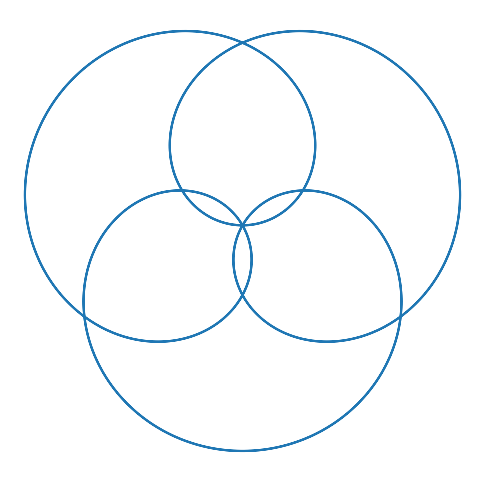

In [6]:
import numpy as np
import matplotlib.pyplot as plt

t = np.linspace(0, 2*np.pi, 1000)

x = np.sin(3*t) * np.cos(5*t)
y = np.sin(3*t) * np.sin(5*t)

plt.figure(figsize=(6,6))
plt.plot(x, y)
plt.axis('equal')
plt.axis('off')
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/kolam_patterns.png'

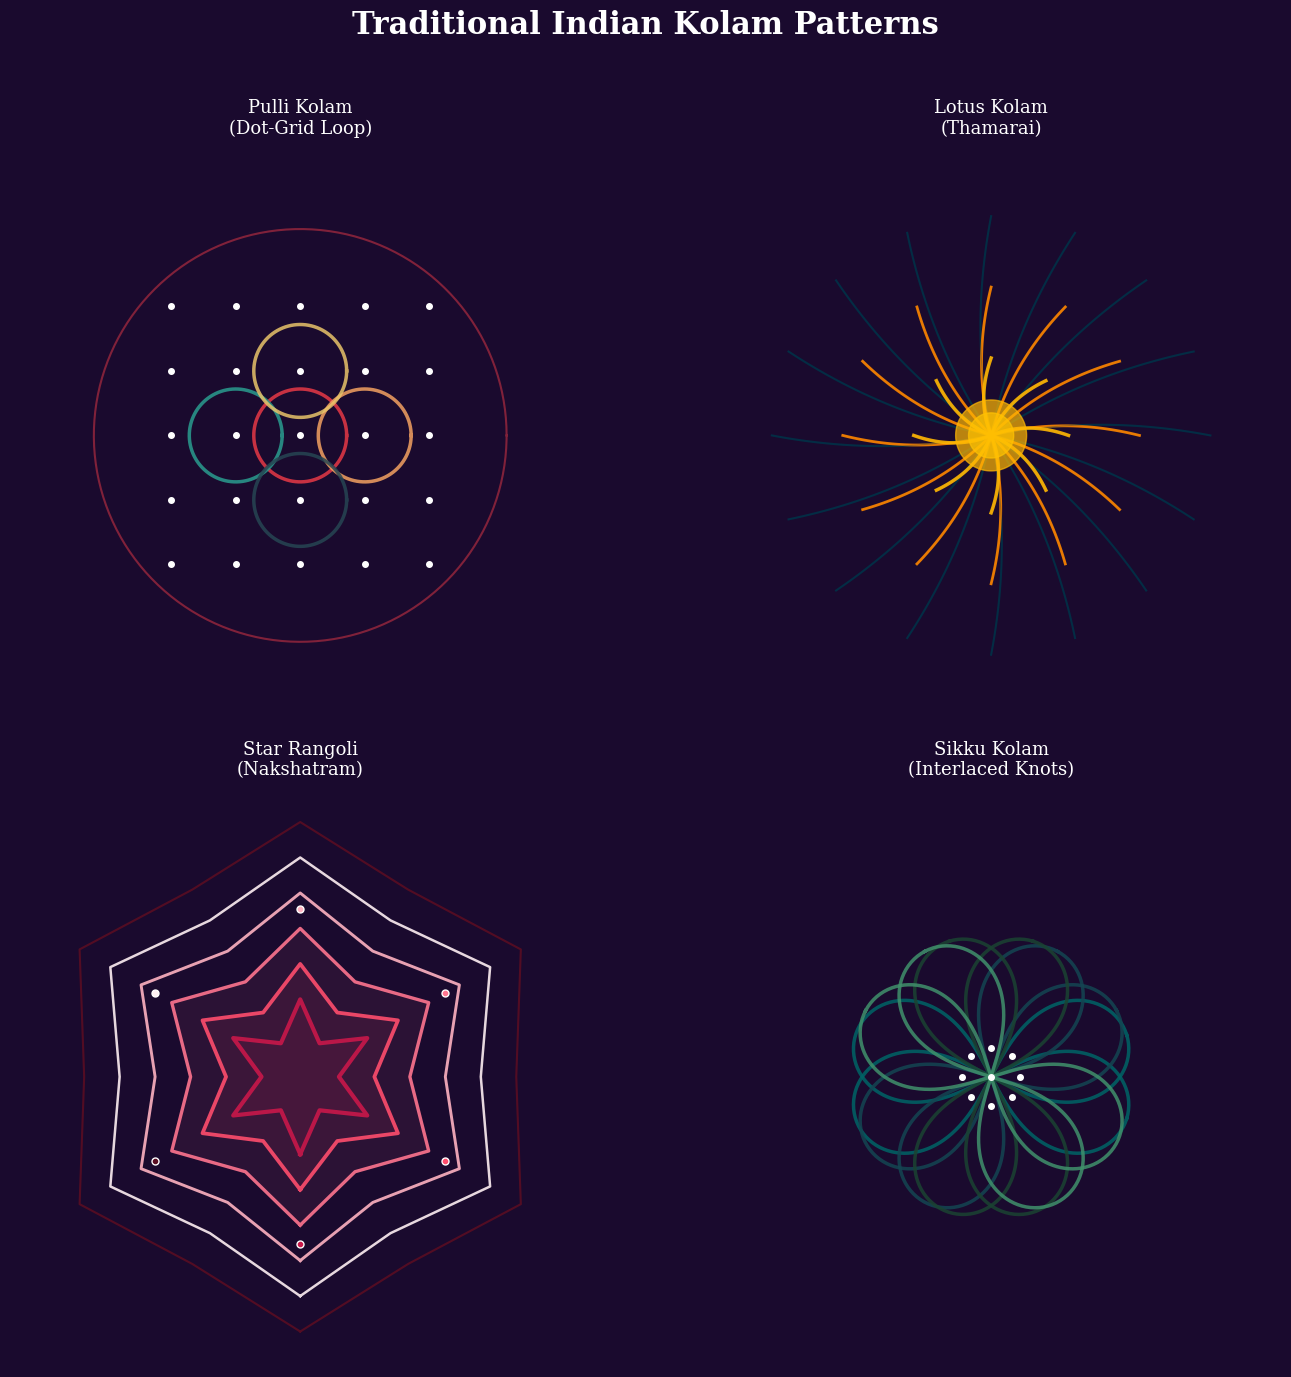

In [7]:
"""
Traditional Indian Kolam Art Generator
Draws beautiful kolam patterns using matplotlib and numpy.
Run: python kolam_art.py
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import FancyArrowPatch
import matplotlib.patheffects as pe
from matplotlib.lines import Line2D


# ── Color palettes ────────────────────────────────────────────────────────────
PALETTES = {
    "rangoli":    ["#E63946", "#F4A261", "#2A9D8F", "#E9C46A", "#264653", "#A8DADC"],
    "turmeric":   ["#FFB703", "#FB8500", "#023047", "#219EBC", "#8ECAE6", "#FFDD00"],
    "temple":     ["#C9184A", "#FF4D6D", "#FF758F", "#FFB3C1", "#FFF0F3", "#590D22"],
    "peacock":    ["#006466", "#144552", "#1B4332", "#40916C", "#74C69D", "#D8F3DC"],
}

BG_COLORS = {
    "rangoli": "#1A0A2E",
    "turmeric": "#0D1B2A",
    "temple":   "#0A0005",
    "peacock":  "#051014",
}


def make_figure(bg):
    fig, ax = plt.subplots(figsize=(10, 10), facecolor=bg)
    ax.set_facecolor(bg)
    ax.set_aspect("equal")
    ax.axis("off")
    return fig, ax


# ─────────────────────────────────────────────────────────────────────────────
# Pattern 1 – Pulli Kolam (dot-grid with looping lines)
# ─────────────────────────────────────────────────────────────────────────────
def draw_pulli_kolam(ax, colors, cx=0, cy=0, scale=1.0):
    """Classic looping lines around a 5×5 dot grid."""
    dot_gap = 1.0 * scale
    rows, cols = 5, 5

    # dots
    for r in range(rows):
        for c in range(cols):
            x = cx + (c - cols // 2) * dot_gap
            y = cy + (r - rows // 2) * dot_gap
            ax.plot(x, y, "o", color="white", ms=4 * scale, zorder=5)

    # looping curves around dots
    def loop(x0, y0, dx, dy, col, lw=2):
        t = np.linspace(0, 2 * np.pi, 200)
        rx, ry = abs(dx) * 0.6, abs(dy) * 0.6
        px = x0 + rx * np.cos(t)
        py = y0 + ry * np.sin(t)
        ax.plot(px, py, color=col, lw=lw * scale, alpha=0.85, zorder=3)

    pair_offsets = [
        (0, 0, 1.2, 1.2),
        (1, 0, 1.2, 1.2),
        (-1, 0, 1.2, 1.2),
        (0, 1, 1.2, 1.2),
        (0, -1, 1.2, 1.2),
    ]
    for i, (ox, oy, dx, dy) in enumerate(pair_offsets):
        loop(cx + ox * dot_gap, cy + oy * dot_gap, dx * scale, dy * scale,
             colors[i % len(colors)], lw=2.5)

    # outer decorative border
    theta = np.linspace(0, 2 * np.pi, 300)
    r_outer = 3.2 * scale
    ax.plot(cx + r_outer * np.cos(theta), cy + r_outer * np.sin(theta),
            color=colors[0], lw=1.5 * scale, alpha=0.5, zorder=2)


# ─────────────────────────────────────────────────────────────────────────────
# Pattern 2 – Lotus Kolam
# ─────────────────────────────────────────────────────────────────────────────
def draw_lotus_kolam(ax, colors, cx=0, cy=0, scale=1.0, petals=8):
    """Concentric lotus layers with petal curves."""
    for layer in range(3):
        r = (1.2 + layer * 1.1) * scale
        n = petals + layer * 4
        col = colors[layer % len(colors)]
        for i in range(n):
            angle = 2 * np.pi * i / n
            mid_angle = angle + np.pi / n
            tip_x = cx + r * np.cos(angle)
            tip_y = cy + r * np.sin(angle)
            ctrl_x = cx + r * 0.5 * np.cos(mid_angle)
            ctrl_y = cy + r * 0.5 * np.sin(mid_angle)
            # bezier-like petal
            t = np.linspace(0, 1, 80)
            bx = (1 - t) ** 2 * cx + 2 * (1 - t) * t * ctrl_x + t ** 2 * tip_x
            by = (1 - t) ** 2 * cy + 2 * (1 - t) * t * ctrl_y + t ** 2 * tip_y
            ax.plot(bx, by, color=col, lw=(2.5 - layer * 0.5) * scale,
                    alpha=0.9, zorder=4 - layer)
            # return stroke
            ax.plot(bx[::-1] * 0 + bx, by, color=col, lw=0.8 * scale,
                    alpha=0.3, zorder=3)

    # centre circle
    theta = np.linspace(0, 2 * np.pi, 200)
    for ri, col in zip([0.35, 0.55], [colors[-1], colors[0]]):
        ax.fill(cx + ri * scale * np.cos(theta),
                cy + ri * scale * np.sin(theta),
                color=col, alpha=0.7, zorder=6)


# ─────────────────────────────────────────────────────────────────────────────
# Pattern 3 – Star / Rangoli Kolam
# ─────────────────────────────────────────────────────────────────────────────
def draw_star_kolam(ax, colors, cx=0, cy=0, scale=1.0, arms=6):
    """Multi-arm star with interlaced triangles."""
    for layer in range(arms):
        r_inner = (0.6 + layer * 0.55) * scale
        r_outer = (1.2 + layer * 0.55) * scale
        col = colors[layer % len(colors)]
        pts = []
        for k in range(arms * 2):
            angle = np.pi / arms * k - np.pi / 2
            r = r_outer if k % 2 == 0 else r_inner
            pts.append([cx + r * np.cos(angle), cy + r * np.sin(angle)])
        pts = np.array(pts + [pts[0]])
        ax.plot(pts[:, 0], pts[:, 1], color=col,
                lw=(3 - layer * 0.3) * scale, alpha=0.9, zorder=5 - layer)
        if layer < 3:
            poly = plt.Polygon(pts[:-1], closed=True, fill=True,
                               facecolor=col, alpha=0.08, zorder=1)
            ax.add_patch(poly)

    # dot accents
    for k in range(arms):
        angle = 2 * np.pi * k / arms - np.pi / 2
        r_d = 2.6 * scale
        ax.plot(cx + r_d * np.cos(angle), cy + r_d * np.sin(angle),
                "o", color="white", ms=5 * scale, zorder=8)
        ax.plot(cx + r_d * np.cos(angle), cy + r_d * np.sin(angle),
                "o", color=colors[k % len(colors)], ms=3 * scale, zorder=9)


# ─────────────────────────────────────────────────────────────────────────────
# Pattern 4 – Sikku Kolam (interlaced curves)
# ─────────────────────────────────────────────────────────────────────────────
def draw_sikku_kolam(ax, colors, cx=0, cy=0, scale=1.0):
    """Sikku (knotted) style with interlaced figure-eight loops."""
    for i in range(4):
        angle = np.pi / 4 * i
        col = colors[i % len(colors)]
        for sign in [1, -1]:
            t = np.linspace(0, 2 * np.pi, 400)
            # lemniscate-like
            r = 2.2 * scale
            x = r * np.cos(t) / (1 + np.sin(t) ** 2)
            y = r * np.sin(t) * np.cos(t) / (1 + np.sin(t) ** 2)
            # rotate
            c_a, s_a = np.cos(angle + sign * 0.3), np.sin(angle + sign * 0.3)
            xr = cx + c_a * x - s_a * y
            yr = cy + s_a * x + c_a * y
            ax.plot(xr, yr, color=col, lw=2.5 * scale, alpha=0.85, zorder=4)

    # centre dot cluster
    for k in range(9):
        ang = 2 * np.pi * k / 8 if k > 0 else 0
        rd = 0 if k == 0 else 0.45 * scale
        ax.plot(cx + rd * np.cos(ang), cy + rd * np.sin(ang),
                "o", color="white", ms=4 * scale, zorder=9)


# ─────────────────────────────────────────────────────────────────────────────
# Main
# ─────────────────────────────────────────────────────────────────────────────
def main():
    palette_name = "rangoli"
    colors = PALETTES[palette_name]
    bg     = BG_COLORS[palette_name]

    fig, axes = plt.subplots(2, 2, figsize=(14, 14), facecolor=bg)
    fig.suptitle("Traditional Indian Kolam Patterns",
                 fontsize=22, color="white", fontweight="bold", y=0.98,
                 fontfamily="serif")

    titles = [
        "Pulli Kolam\n(Dot-Grid Loop)",
        "Lotus Kolam\n(Thamarai)",
        "Star Rangoli\n(Nakshatram)",
        "Sikku Kolam\n(Interlaced Knots)",
    ]
    draw_fns = [draw_pulli_kolam, draw_lotus_kolam,
                draw_star_kolam,  draw_sikku_kolam]

    for ax, title, fn, pal_key in zip(
            axes.flat, titles, draw_fns,
            ["rangoli", "turmeric", "temple", "peacock"]):

        ax.set_facecolor(BG_COLORS[pal_key])
        ax.set_aspect("equal")
        ax.axis("off")
        ax.set_xlim(-4.5, 4.5)
        ax.set_ylim(-4.5, 4.5)
        ax.set_title(title, color="white", fontsize=13,
                     fontfamily="serif", pad=8)
        fn(ax, PALETTES[pal_key], scale=1.0)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    out = "/mnt/user-data/outputs/kolam_patterns.png"
    plt.savefig(out, dpi=150, bbox_inches="tight", facecolor=bg)
    print(f"Saved → {out}")
    plt.show()


if __name__ == "__main__":
    main()